In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/finalmachinelearning')

import pandas as pd
import numpy as np

sx_data = pd.read_csv('douyin_dataset.csv')
sx_data.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Unnamed: 0,uid,user_city,item_id,author_id,item_city,channel,finish,like,music_id,duration_time,real_time,H,date
0,3,15692,109.0,691661,18212,213.0,0,0,0,11513.0,10,2019-10-28 21:55:10,21,2019-10-28
1,5,44071,80.0,1243212,34500,68.0,0,0,0,1274.0,9,2019-10-21 22:27:03,22,2019-10-21
2,16,10902,202.0,3845855,634066,113.0,0,0,0,762.0,10,2019-10-26 00:38:51,0,2019-10-26
3,19,25300,21.0,3929579,214923,330.0,0,0,0,2332.0,15,2019-10-25 20:36:25,20,2019-10-25
4,24,3656,138.0,2572269,182680,80.0,0,0,0,238.0,9,2019-10-21 20:46:29,20,2019-10-21


# Project Overview
This supports the final project by documenting the data cleaning,
feature engineering, and modeling steps used to analyze user behavior patterns
on TikTok.



# Data import and preprocessing

### Data Import
I begin by loading the tiktok user interaction dataset and inspecting its basic structure.


In [ ]:
# Import package
import pandas as pd
import numpy as np
# Simple data processing reading in data
sx_data = pd.read_csv('/content/drive/MyDrive/finalmachinelearning/douyin_dataset.csv')

sx_data.head()


,Unnamed: 0,uid,user_city,item_id,author_id,item_city,channel,finish,like,music_id,duration_time,real_time,H,date
0,3,15692,109.0,691661,18212,213.0,0,0,0,11513.0,10,2019-10-28 21:55:10,21,2019-10-28
1,5,44071,80.0,1243212,34500,68.0,0,0,0,1274.0,9,2019-10-21 22:27:03,22,2019-10-21
2,16,10902,202.0,3845855,634066,113.0,0,0,0,762.0,10,2019-10-26 00:38:51,0,2019-10-26
3,19,25300,21.0,3929579,214923,330.0,0,0,0,2332.0,15,2019-10-25 20:36:25,20,2019-10-25
4,24,3656,138.0,2572269,182680,80.0,0,0,0,238.0,9,2019-10-21 20:46:29,20,2019-10-21


In [ ]:
#Delete invalid field [Unnamed:0]
del sx_data['Unnamed: 0']

In [ ]:
# Basic data information
sx_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1737312 entries, 0 to 1737311
Data columns (total 13 columns):
 #   Column         Dtype  
---  ------         -----  
 0   uid            int64  
 1   user_city      float64
 2   item_id        int64  
 3   author_id      int64  
 4   item_city      float64
 5   channel        int64  
 6   finish         int64  
 7   like           int64  
 8   music_id       float64
 9   duration_time  int64  
 10  real_time      object 
 11  H              int64  
 12  date           object 
dtypes: float64(3), int64(8), object(2)
memory usage: 172.3+ MB


In [ ]:
print('Before deduplication: ', sx_data.shape[0], 'row data')
print('After deduplication: ', sx_data.drop_duplicates().shape[0], 'row data')
# No duplicate rows detected, dataset remains unchanged



Before deduplication:  1737312 row data
After deduplication:  1737312 row data


In [ ]:
# Count the number of null values
print(sx_data.isnull().sum())

uid              0
user_city        0
item_id          0
author_id        0
item_city        0
channel          0
finish           0
like             0
music_id         0
duration_time    0
real_time        0
H                0
date             0
dtype: int64


In [ ]:
# Feature Indicator Statistical Analysis
#1. User Feature Statistical Analysis
user_sx_df = pd.DataFrame()
user_sx_df['uid'] = sx_data.groupby('uid')['like'].count().index.tolist() # Extract all users' uids into a uid column
user_sx_df.set_index('uid', inplace=True) # Set the uid column as index for automatic data alignment
user_sx_df['Views'] = sx_data.groupby('uid')['like'].count() # Count the number of views for each uid
user_sx_df['Likes'] = sx_data.groupby('uid')['like'].sum() # Count the number of likes for each uid
user_sx_df['Views by Authors'] = sx_data.groupby(['uid']).agg({'author_id':pd.Series.nunique}) # Number of author views

user_sx_df['Number of viewed works'] = sx_data.groupby(['uid']).agg({'item_id':pd.Series.nunique}) # Number of viewed works

user_sx_df['Average viewing time'] = sx_data.groupby(['uid'])['duration_time'].mean() # Average viewing time

user_sx_df['Number of viewed background music'] = sx_data.groupby(['uid']).agg({'music_id':pd.Series.nunique}) # Number of background music tracks in viewed works

user_sx_df['Number of complete views'] = sx_data.groupby('uid')['finish'].sum() # Count the total number of views for the corresponding uid

# Count the number of cities visited by the corresponding uid
user_sx_df['number of cities visited'] = sx_data.groupby(['uid']).agg({'user_city':pd.Series.nunique})

# Count the number of cities where the corresponding uid's viewed works are located
user_sx_df['number of cities viewed works'] = sx_data.groupby(['uid']).agg({'item_city':pd.Series.nunique})

user_sx_df.describe()

user_sx_df.to_csv('user characteristics.csv', encoding='utf_8_sig')

In [ ]:
#2. Statistical Analysis of Author Characteristics
item_time = sx_data.groupby(['author_id', 'item_id'])

In [ ]:
sx_data['date'] = pd.to_datetime(sx_data['date'])
sx_data['real_time'] = pd.to_datetime(sx_data['real_time'])

# Create an item_time DataFrame
item_time = sx_data.groupby(['author_id', 'item_id']).mean().reset_index()

In [ ]:
print(type(item_time))

<class 'pandas.core.frame.DataFrame'>


### User level feature construction

I aggregate interaction logs to derive per user behavioral features.


In [ ]:
author_sx_df = pd.DataFrame()

author_sx_df['author_id'] = sx_data.groupby('author_id')['like'].count().index.tolist()
author_sx_df.set_index('author_id', inplace=True)

author_sx_df['total_views'] = sx_data.groupby('author_id')['like'].count()
author_sx_df['total_likes']  = sx_data.groupby('author_id')['like'].sum()
author_sx_df['total_finishes']  = sx_data.groupby('author_id')['finish'].sum()
author_sx_df['total_items'] = sx_data.groupby('author_id').agg({'item_id': pd.Series.nunique})
author_sx_df['avg_item_duration'] = item_time.groupby('author_id')['duration_time'].mean()

author_sx_df['unique_music_count'] = sx_data.groupby('author_id').agg({'music_id': pd.Series.nunique})

author_sx_df['unique_post_days'] = sx_data.groupby('author_id').agg({'real_time': pd.Series.nunique})

author_sx_days = sx_data.groupby('author_id')['date']
_ = pd.to_datetime(author_sx_days.max()) - pd.to_datetime(author_sx_days.min())

author_sx_df['unique_cities'] = sx_data.groupby('author_id').agg({'item_city': pd.Series.nunique})

author_sx_df.describe()

author_sx_df.to_csv('author_features.csv', encoding='utf_8_sig')


In [ ]:
# 3. Item feature statistics
item_sx_df = pd.DataFrame()

item_sx_df['item_id'] = sx_data.groupby('item_id')['like'].count().index.tolist()
item_sx_df.set_index('item_id', inplace=True)


item_sx_df['views'] = sx_data.groupby('item_id')['like'].count()
item_sx_df['likes'] = sx_data.groupby('item_id')['like'].sum()


item_sx_df['post_city'] = sx_data.groupby('item_id')['item_city'].mean()
item_sx_df['background_music'] = sx_data.groupby('item_id')['music_id'].mean()


item_sx_df.to_csv('item_features.csv', encoding='utf_8_sig')


# Exploratory data analysis

## Interpretation note
This correlation matrix is used as a preliminary exploration.
Several variables in the dataset represent IDs rather than meaningful numerical values.
Therefore, the correlations here are not intended to explain user behavior directly.
Instead, they help motivate the shift toward higher-level behavioral features used in the following analysis.

<Axes: >

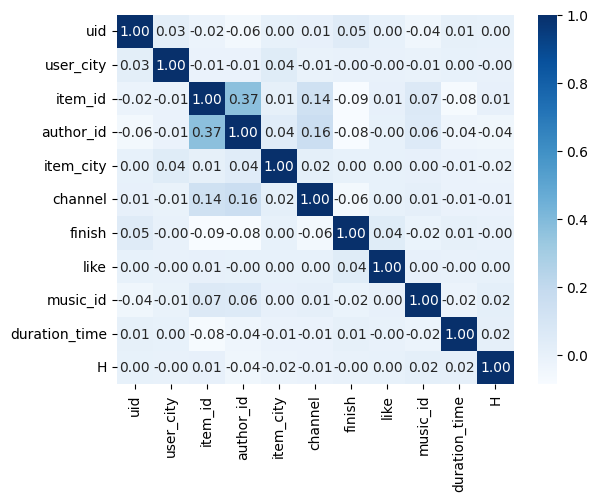

In [ ]:
import seaborn as sns  # Make sure to import seaborn before using sns

numeric_columns = sx_data.select_dtypes(include=['float', 'int']).columns

# Calculate correlations
correlations = sx_data[numeric_columns].corr()

# Plot heatmap
sns.heatmap(correlations, annot=True, cmap='Blues', fmt='.2f')




### Data Visualization  User Feature Analysis


In [ ]:
import matplotlib.pyplot as plt

def line_chart(t, data):
    """
    Line chart using matplotlib
    t: title (str)
    data: list of (x, y) pairs
    """
    x = [i[0] for i in data]
    y = [i[1] for i in data]

    plt.figure(figsize=(6, 4))
    plt.plot(x, y, linewidth=2)
    plt.fill_between(x, y, alpha=0.3)

    plt.title(t)
    plt.xlabel("Category")
    plt.ylabel("Value")
    plt.grid(True)

    plt.tight_layout()
    plt.show()


In [ ]:
import matplotlib.pyplot as plt

def pie_chart(t, data_pair, save_path=None):
    labels = [i[0] for i in data_pair]
    sizes = [i[1] for i in data_pair]

    plt.figure(figsize=(5.5, 3))
    plt.pie(
        sizes,
        labels=labels,
        autopct='%1.1f%%',
        startangle=90
    )
    plt.title(t)
    plt.axis('equal')  #  guaranteed to be a perfect circle.
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300)

    plt.show()


In [ ]:
import matplotlib.pyplot as plt

def fl_chart(t, data, save_path=None):
    """
    Funnel-style chart using horizontal bar chart
    t: title (str)
    data: list of (label, value)
    """
    labels = [i[0] for i in data]
    values = [i[1] for i in data]

    # Reverse the order so that the funnel becomes smaller from top to bottom.
    labels = labels[::-1]
    values = values[::-1]

    plt.figure(figsize=(6, 3))
    plt.barh(labels, values)
    plt.title(t)
    plt.xlabel("Percentage")

    # Label the percentage at the end of the bar.
    for i, v in enumerate(values):
        plt.text(v, i, f"{v}%", va='center')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300)

    plt.show()


In [ ]:
user_df = pd.read_csv('/content/drive/MyDrive/finalmachinelearning/user characteristics.csv')
user_df.head()


,uid,Views,Likes,Views by Authors,Number of viewed works,Average viewing time,Number of viewed background music,Number of complete views,number of cities visited,number of cities viewed works
0,0,34,0,31,34,12.058824,31,18,1,28
1,1,28,1,28,28,12.357143,26,14,1,25
2,2,56,0,56,56,10.357143,47,19,3,45
3,3,117,1,116,117,9.982906,89,60,1,76
4,4,123,0,117,123,10.853659,94,77,1,84


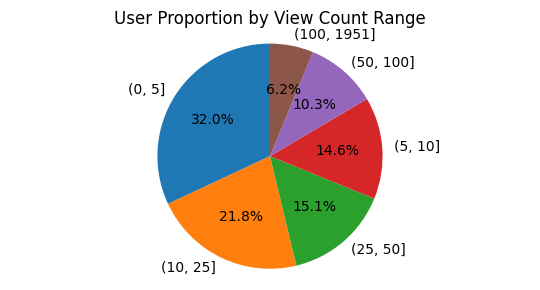

In [ ]:
bins = [0, 5, 10, 25, 50, 100, 1951]
data = pd.cut(user_df['Views'], bins, right=True,
              labels=[f'({bins[x]}, {bins[x+1]}]'
                      for x in range(len(bins)-1)]).value_counts().reset_index().values.tolist()

pie_chart('User Proportion by View Count Range', data)


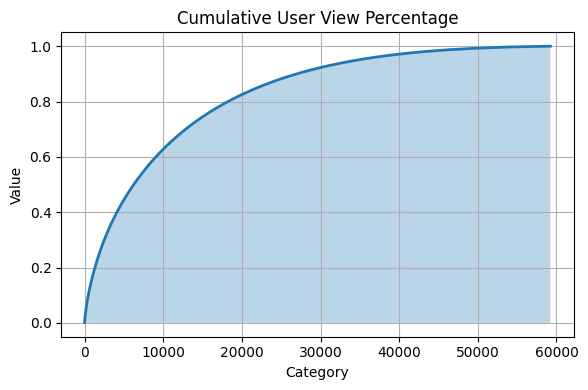

In [ ]:
temp = user_df['Views'].sort_values(ascending=False).cumsum()
temp = temp / temp.max()
data = list(enumerate(temp.tolist()))

line_chart('Cumulative User View Percentage', data)




In [ ]:
_ = temp.tolist()
for j in range(10):
    j /= 10
    for i in _:
        if i >= j:
            flag = i
            break
    c = _.index(flag) / len(_)
    print(f'{c:4.1%} of users contributed {j:3.0%} of the likes')


0.0% of users contributed  0% of the likes
0.8% of users contributed 10% of the likes
2.2% of users contributed 20% of the likes
4.2% of users contributed 30% of the likes
6.9% of users contributed 40% of the likes
10.6% of users contributed 50% of the likes
15.3% of users contributed 60% of the likes
21.7% of users contributed 70% of the likes
30.8% of users contributed 80% of the likes
45.6% of users contributed 90% of the likes


In [ ]:
import matplotlib.pyplot as plt

def line_chart(t, data):
    """
    Line chart using matplotlib
    t: title (str)
    data: list of (x, y) pairs
    """
    x = [i[0] for i in data]
    y = [i[1] for i in data]

    plt.figure(figsize=(6, 4))
    plt.plot(x, y, linewidth=2)
    plt.fill_between(x, y, alpha=0.3)

    plt.title(t)
    plt.xlabel("Category")
    plt.ylabel("Value")
    plt.grid(True)

    plt.tight_layout()
    plt.show()


In [ ]:
print(user_df.columns.tolist())


['uid', 'Views', 'Likes', 'Views by Authors', 'Number of viewed works', 'Average viewing time', 'Number of viewed background music', 'Number of complete views', 'number of cities visited', 'number of cities viewed works']


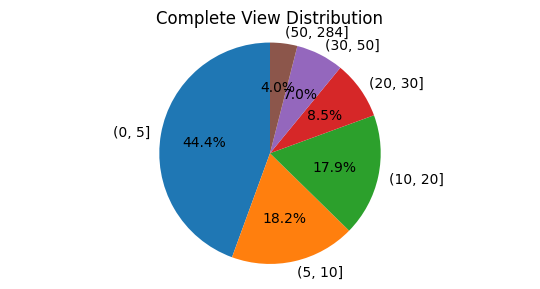

In [ ]:
bins = [0, 5, 10, 20, 30, 50, 284]
labels = [f'({bins[i]}, {bins[i+1]}]' for i in range(len(bins)-1)]

cut = pd.cut(user_df['Number of complete views'], bins=bins, right=True, labels=labels)

data = (
    cut.value_counts()
       .reindex(labels)          # Let the intervals be sorted by bins
       .reset_index()
       .values.tolist()
)

pie_chart('Complete View Distribution', data)


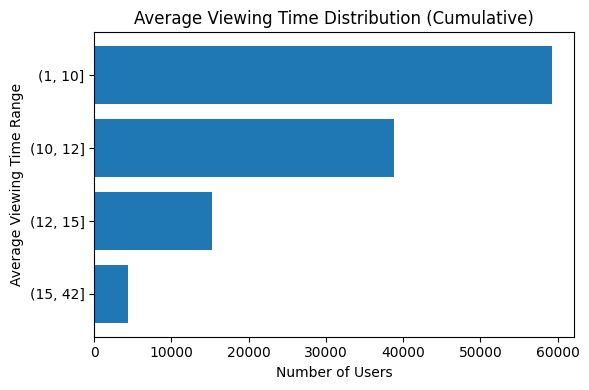

In [ ]:


# Column name
COL_AVG_TIME = 'Average viewing time'

# Define bins
bins = [1, 10, 12, 15, 42]
labels = [f'({bins[i]}, {bins[i+1]}]' for i in range(len(bins)-1)]

# Bin the data
cut = pd.cut(
    user_df[COL_AVG_TIME],
    bins=bins,
    right=True,
    labels=labels
)

# Count users in each bin
counts = cut.value_counts().reindex(labels)

# Cumulative distribution (from high to low)
cum_counts = counts.iloc[::-1].cumsum().iloc[::-1]

# Plot funnel-style chart
plt.figure(figsize=(6, 4))
plt.barh(cum_counts.index, cum_counts.values)
plt.gca().invert_yaxis()  # Top bin at top

plt.title('Average Viewing Time Distribution (Cumulative)')
plt.xlabel('Number of Users')
plt.ylabel('Average Viewing Time Range')

plt.tight_layout()
plt.show()


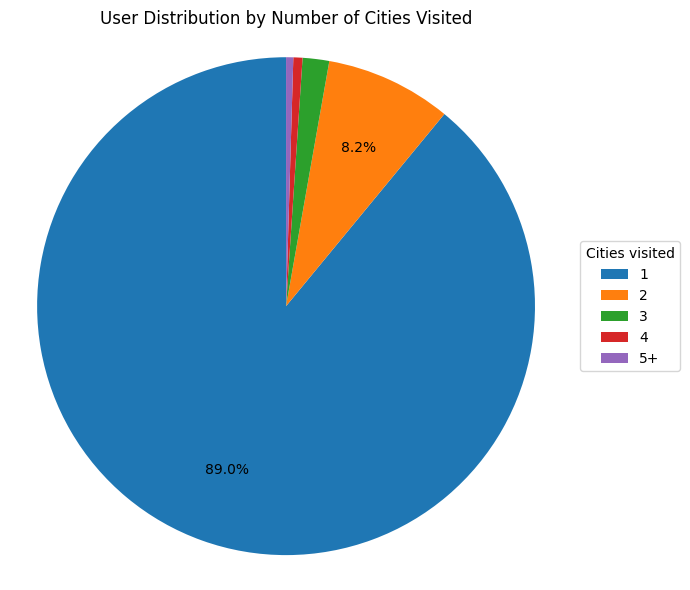

In [ ]:
import matplotlib.pyplot as plt

COL_CITIES = 'number of cities visited'

counts = user_df[COL_CITIES].value_counts()

# Merge 5+ into one bucket
counts_merged = counts[counts.index < 5].copy()
counts_merged.loc['5+'] = counts[counts.index >= 5].sum()

order = [1, 2, 3, 4, '5+']   # change to [0,1,2,3,4,'5+']
counts_merged = counts_merged.reindex(order, fill_value=0)

labels = counts_merged.index.astype(str)
sizes = counts_merged.values

def autopct_if_big(pct):
    return f'{pct:.1f}%' if pct >= 3 else ''   # only show >= 3%

plt.figure(figsize=(7, 6))
wedges, texts, autotexts = plt.pie(
    sizes,
    labels=None,                 # remove labels on the pie (prevents crowding)
    autopct=autopct_if_big,      # only show big percentages
    startangle=90,
    pctdistance=0.7
)

plt.title('User Distribution by Number of Cities Visited')
plt.axis('equal')

# Put labels in legend instead of around the pie
plt.legend(
    wedges,
    labels,
    title='Cities visited',
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout()
plt.show()


### Data Visualization Author Feature Analysis

In [ ]:
import pandas as pd
import numpy as np




In [ ]:
def line_chart(t, data):
    chart = (
        Line(init_opts = opts.InitOpts(theme='light', width='500px', height='300px'))
        .add_xaxis([i[0] for i in data])
        .add_yaxis(
            '',
            [i[1] for i in data],
            is_symbol_show=False,
            areastyle_opts=opts.AreaStyleOpts(opacity=1, color="cyan")
        )
        .set_global_opts(
            title_opts=opts.TitleOpts(title=t),
            xaxis_opts=opts.AxisOpts(type_="category", boundary_gap=True),
            yaxis_opts=opts.AxisOpts(
                type_="value",
                axistick_opts=opts.AxisTickOpts(is_show=True),
                splitline_opts=opts.SplitLineOpts(is_show=True),
            ),
        )
    )
    return chart


In [ ]:
def pie_chart(t, data_pair):
    # Create a new pie chart
    chart = (
        Pie(init_opts=opts.InitOpts(theme='light', width='550px', height='300px'))
        .add(
            '', data_pair, radius=["30%", "45%"],  # Radius range: inner and outer radius
            label_opts=opts.LabelOpts(formatter="{b}: {d}%")  # Label settings, {d} shows percentage
        )
        .set_global_opts(
            title_opts=opts.TitleOpts(
                title=t
            ),
            legend_opts=opts.LegendOpts(pos_left="0%", pos_top="55", orient='vertical')
        )
    )
    return chart


In [ ]:
author_df = pd.read_csv('author_features.csv')
author_df.head()


,author_id,total_views,total_likes,total_finishes,total_items,avg_item_duration,unique_music_count,unique_post_days,unique_cities
0,0,1,0,0,1,10.000000,1,1,1
1,1,16,0,8,3,8.333333,3,3,1
2,3,311,3,203,1,9.000000,1,1,1
3,5,1054,33,485,5,8.200000,4,5,1
4,8,4,0,3,1,19.000000,1,1,1


In [ ]:
print(author_df.columns.tolist())


['author_id', 'total_views', 'total_likes', 'total_finishes', 'total_items', 'avg_item_duration', 'unique_music_count', 'unique_post_days', 'unique_cities']


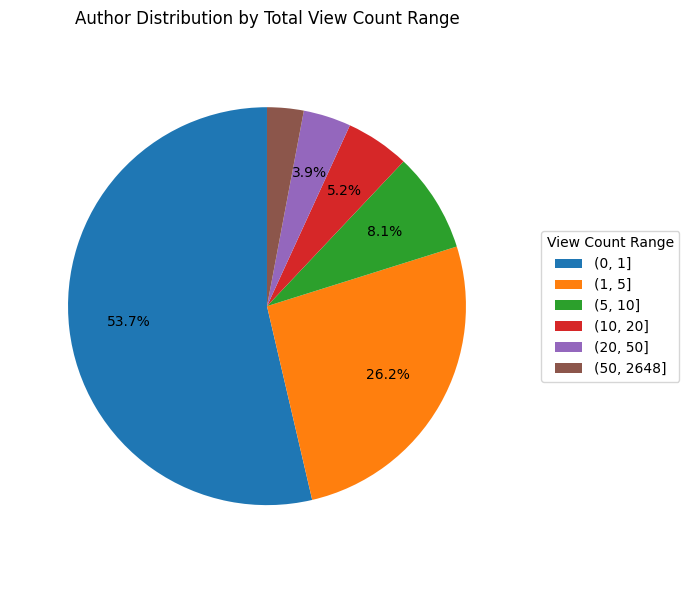

In [ ]:


COL_VIEWS = 'total_views'

bins = [0, 1, 5, 10, 20, 50, 2648]
labels = [f'({bins[i]}, {bins[i+1]}]' for i in range(len(bins) - 1)]

cut = pd.cut(author_df[COL_VIEWS], bins=bins, right=True, labels=labels, include_lowest=True)
counts = cut.value_counts().reindex(labels, fill_value=0)

def autopct_if_big(pct):
    return f'{pct:.1f}%' if pct >= 3 else ''

plt.figure(figsize=(7, 6))
wedges, _, _ = plt.pie(
    counts.values,
    labels=None,
    autopct=autopct_if_big,
    startangle=90,
    pctdistance=0.7
)

plt.title('Author Distribution by Total View Count Range')
plt.axis('equal')

plt.legend(
    wedges,
    counts.index.astype(str),
    title='View Count Range',
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt

def line_chart(title, data):
    x = [i[0] for i in data]
    y = [i[1] for i in data]

    plt.figure(figsize=(6, 4))
    plt.plot(x, y, linewidth=2)
    plt.fill_between(x, y, alpha=0.3)
    plt.title(title)
    plt.xlabel("Author Rank")
    plt.ylabel("Cumulative Share of Total Views")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


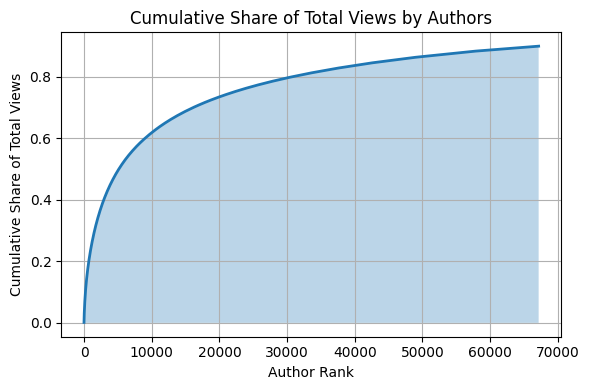

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

# Column name
COL_VIEWS = 'total_views'

# Sort authors by total views (descending)
temp = author_df[COL_VIEWS].sort_values(ascending=False).reset_index(drop=True)

# Cumulative share
cum_share = temp.cumsum()
cum_share = cum_share / cum_share.max()

# Build dataframe for plotting
plot_df = pd.DataFrame({
    'rank': range(1, len(cum_share) + 1),
    'cumulative_share': cum_share
})

# Keep authors contributing to the first 90%
plot_df = plot_df[plot_df['cumulative_share'] < 0.90]

# Prepare data for line_chart: [(x, y), ...]
data = list(zip(plot_df['rank'], plot_df['cumulative_share']))

# Plot
line_chart('Cumulative Share of Total Views by Authors', data)


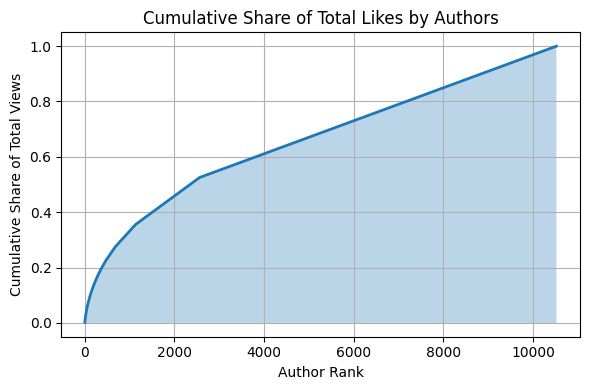

In [ ]:

# Column name
COL_LIKES = 'total_likes'

# Sort authors by total likes
temp = author_df[COL_LIKES].sort_values(ascending=False).reset_index(drop=True)

# Cumulative share of likes
cum_share = temp.cumsum()
cum_share = cum_share / cum_share.max()

# Build dataframe for plotting
plot_df = pd.DataFrame({
    'rank': range(1, len(cum_share) + 1),
    'cumulative_share': cum_share
})

# Keep values below ~100%
plot_df = plot_df[plot_df['cumulative_share'] < 0.9999999999999999]

# Prepare data for line_chart
data = list(zip(plot_df['rank'], plot_df['cumulative_share']))

# Plot
line_chart('Cumulative Share of Total Likes by Authors', data)


In [ ]:
print(author_df.columns.tolist())


['author_id', 'total_views', 'total_likes', 'total_finishes', 'total_items', 'avg_item_duration', 'unique_music_count', 'unique_post_days', 'unique_cities']


In [ ]:
print(type(temp))


<class 'pandas.core.series.Series'>


In [ ]:
likes_sorted = author_df['total_likes'].sort_values(ascending=False).reset_index(drop=True)
cum_share = likes_sorted.cumsum() / likes_sorted.sum()

for target in [i/10 for i in range(1, 10)]:
    idx = (cum_share >= target).idxmax()
    author_prop = (idx + 1) / len(cum_share)
    print(f'{author_prop:4.1%} of authors received {target:3.0%} of the likes')


0.1% of authors received 10% of the likes
0.2% of authors received 20% of the likes
0.4% of authors received 30% of the likes
0.7% of authors received 40% of the likes
1.1% of authors received 50% of the likes
1.8% of authors received 60% of the likes
2.6% of authors received 70% of the likes
3.4% of authors received 80% of the likes
4.2% of authors received 90% of the likes


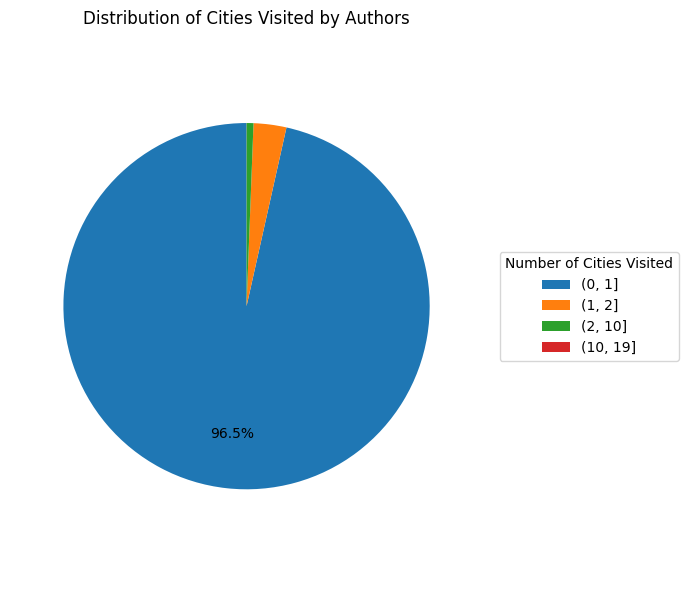

In [ ]:

# Column name
COL_CITIES = 'unique_cities'

# Define bins
bins = [0, 1, 2, 10, 19]
labels = [f'({bins[i]}, {bins[i+1]}]' for i in range(len(bins) - 1)]

# Bin the data
cut = pd.cut(
    author_df[COL_CITIES],
    bins=bins,
    right=True,
    labels=labels,
    include_lowest=True
)

# Count per bin and keep order
counts = cut.value_counts().reindex(labels, fill_value=0)

# Plot pie chart
def autopct_if_big(pct):
    return f'{pct:.1f}%' if pct >= 3 else ''

plt.figure(figsize=(7, 6))
wedges, _, _ = plt.pie(
    counts.values,
    labels=None,
    autopct=autopct_if_big,
    startangle=90,
    pctdistance=0.7
)

plt.title('Distribution of Cities Visited by Authors')
plt.axis('equal')

plt.legend(
    wedges,
    counts.index.astype(str),
    title='Number of Cities Visited',
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout()
plt.show()


### Data Visualization Characteristic Analysis of Works

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import matplotlib.pyplot as plt

def line_chart(title, data, xlabel="Rank", ylabel="Value"):
    x = [i[0] for i in data]
    y = [i[1] for i in data]

    plt.figure(figsize=(6, 4))
    plt.plot(x, y, linewidth=2)
    plt.fill_between(x, y, alpha=0.3)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:


def pie_chart(title, data_pair, legend_title=None):
    labels = [str(i[0]) for i in data_pair]
    values = [i[1] for i in data_pair]

    def autopct_if_big(pct):
        return f'{pct:.1f}%' if pct >= 3 else ''

    plt.figure(figsize=(6, 5))
    wedges, _, _ = plt.pie(
        values,
        labels=None,              # avoid crowding
        autopct=autopct_if_big,
        startangle=90,
        pctdistance=0.7
    )

    plt.title(title)
    plt.axis('equal')

    plt.legend(
        wedges,
        labels,
        title=legend_title,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5)
    )

    plt.tight_layout()
    plt.show()


In [ ]:
sx_data = pd.read_csv('douyin_dataset.csv')
del sx_data['Unnamed: 0']

item_df = pd.read_csv('item_features.csv')
item_df.head()


,item_id,views,likes,post_city,background_music
0,0,24,0,24.0,220.0
1,1,1309,5,63.0,574.0
2,3,2,0,7.0,26289.0
3,4,613,3,146.0,162.0
4,7,2,0,33.0,540.0


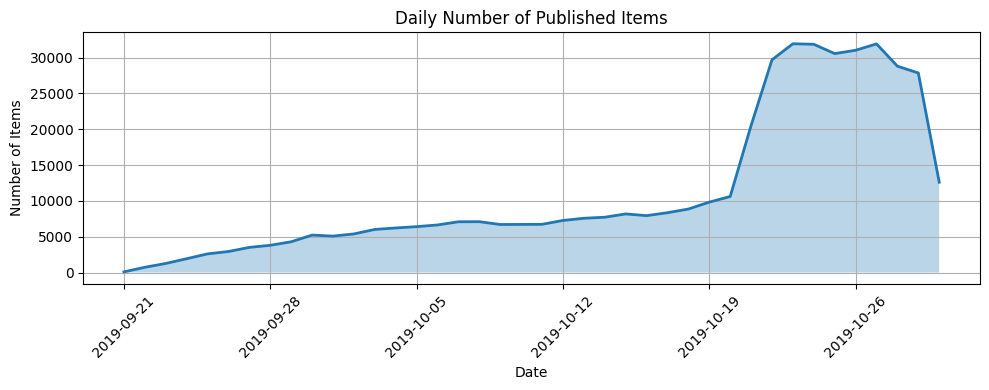

In [ ]:
import matplotlib.pyplot as plt

data = (
    sx_data
    .groupby('date')['item_id']
    .nunique()
    .reset_index()
)

x = data['date']
y = data['item_id']

plt.figure(figsize=(10, 4))
plt.plot(x, y, linewidth=2)
plt.fill_between(x, y, alpha=0.3)

# Show fewer x-axis ticks
plt.xticks(x[::7], rotation=45)   # show one date per week

plt.title("Daily Number of Published Items")
plt.xlabel("Date")
plt.ylabel("Number of Items")
plt.grid(True)
plt.tight_layout()
plt.show()


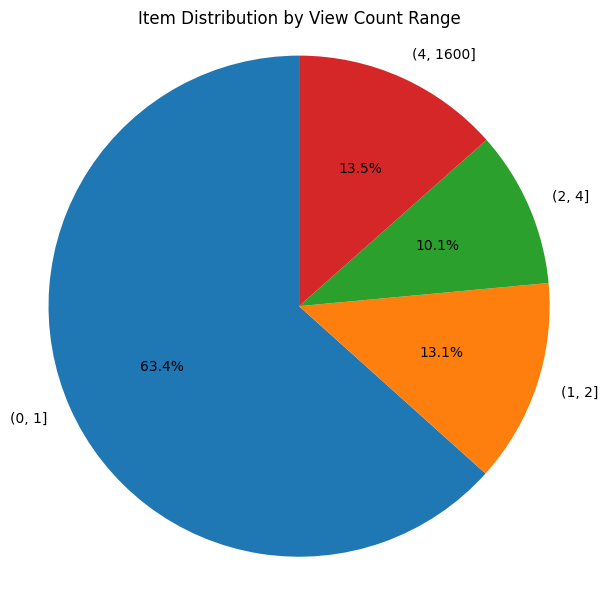

In [ ]:

# Column name
COL_VIEWS = 'views'

# Define bins
bins = [0, 1, 2, 4, 1600]
labels = [f'({bins[i]}, {bins[i+1]}]' for i in range(len(bins) - 1)]

# Create view level categories
item_df['view_level'] = pd.cut(
    item_df[COL_VIEWS],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Count items per view level
counts = (
    item_df['view_level']
    .value_counts()
    .reindex(labels, fill_value=0)
)

# Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Item Distribution by View Count Range')
plt.axis('equal')
plt.tight_layout()
plt.show()


This figure shows the distribution of items across different view count ranges.


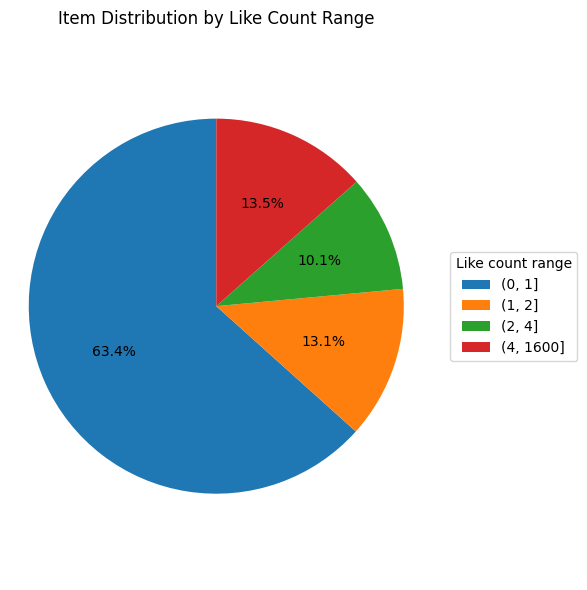

In [ ]:
def autopct_if_large(pct):
    return f'{pct:.1f}%' if pct >= 1 else ''

plt.figure(figsize=(6, 6))
plt.pie(
    counts.values,
    labels=None,
    autopct=autopct_if_large,
    startangle=90
)

plt.legend(
    counts.index,
    title='Like count range',
    loc='center left',
    bbox_to_anchor=(1.05, 0.5)
)

plt.title('Item Distribution by Like Count Range')
plt.axis('equal')
plt.tight_layout()
plt.show()


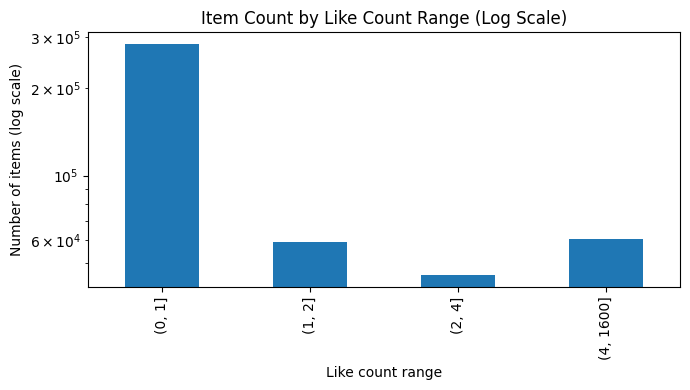

In [ ]:
plt.figure(figsize=(7, 4))
counts.plot(kind='bar')

plt.yscale('log')
plt.title('Item Count by Like Count Range (Log Scale)')
plt.xlabel('Like count range')
plt.ylabel('Number of items (log scale)')
plt.tight_layout()
plt.show()


The distribution is highly skewed: over 97% of items receive at most one like, while only a very small fraction achieve higher engagement levels.

# Data Mining

### 1. Clustering


In [ ]:
import numpy as np
import pandas as pd

import os
import joblib
import numpy as np
from sklearn.cluster import KMeans
from sklearn import metrics

from sklearn.cluster import KMeans
import joblib
from sklearn import metrics
from scipy.spatial.distance import cdist


In [ ]:


user_feature = pd.read_csv('user characteristics.csv')
author_feature = pd.read_csv('author_features.csv')


In [ ]:
user_data = user_feature[
    (user_feature['Number of complete views'] >= 1) &
    (user_feature['Views'] >= 5)
]

print(len(user_data) / len(user_feature))


0.7097514856834144


In [ ]:
author_data = author_feature[(author_feature['total_finishes'] >= 1) &
                             (author_feature['total_views'] >= 3)]
print(len(author_data) / len(author_feature))


0.2990244347629775


In [ ]:


def run_kmeans_grid(X, name, k_min=2, k_max=9, save_dir="models"):
    """
    Run KMeans for K in [k_min, k_max], compute metrics, and save models + scores.

    Parameters
    ----------
    X : array-like (n_samples, n_features)
        Input data for clustering.
    name : str
        Prefix used in saved filenames.
    k_min : int
        Minimum K.
    k_max : int
        Maximum K.
    save_dir : str
        Directory to save models and score files.

    Returns
    -------
    scores : dict
        {'silhouette': [...], 'sse': [...], 'k_values': [...]}
    """
    os.makedirs(save_dir, exist_ok=True)

    k_values = list(range(k_min, k_max + 1))
    scores = {"k_values": [], "silhouette": [], "sse": []}

    for k in k_values:
        model = KMeans(n_clusters=k, init="k-means++", random_state=0, n_init=10)
        labels = model.fit_predict(X)

        # Standard SSE: sum of squared distances to the closest centroid
        sse = model.inertia_

        # Silhouette score requires at least 2 clusters and less than n_samples clusters
        sil = metrics.silhouette_score(X, labels)

        # Save model
        model_path = os.path.join(save_dir, f"{name}_k{k}_kmeans.model")
        joblib.dump(model, model_path)

        scores["k_values"].append(k)
        scores["sse"].append(sse)
        scores["silhouette"].append(sil)

        print(f"K={k} finished. SSE={sse:.2f}, silhouette={sil:.4f}")

    # Save scores
    score_path = os.path.join(save_dir, f"{name}_kmeans_scores.score")
    joblib.dump(scores, score_path)
    print("All scores saved.")

    return scores


In [ ]:
import matplotlib.pyplot as plt

def plot_kmeans_metrics(k_values, sse, silhouette):
    """
    Plot KMeans evaluation metrics using matplotlib.

    Parameters
    ----------
    k_values : list
        Number of clusters (K)
    sse : list
        SSE values
    silhouette : list
        Silhouette scores
    """

    fig, ax1 = plt.subplots(figsize=(6, 4))

    # Left axis: SSE
    ax1.plot(k_values, sse, marker='o', linewidth=2, label='SSE')
    ax1.set_xlabel('Number of Clusters (K)')
    ax1.set_ylabel('SSE')
    ax1.grid(True)

    # Right axis: Silhouette score
    ax2 = ax1.twinx()
    ax2.plot(k_values, silhouette, marker='s', linewidth=2, color='orange', label='Silhouette Score')
    ax2.set_ylabel('Silhouette Score')
    ax2.set_ylim(-1, 1)

    # Title
    plt.title('KMeans Clustering Evaluation')

    # Combined legend
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='best')

    plt.tight_layout()
    plt.show()


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import joblib

def run_kmeans_and_save(X, name_prefix, k_range=range(2, 10)):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    scores = {'sse': [], 'sc': []}

    for k in k_range:
        km = KMeans(n_clusters=k, random_state=0, n_init=10)
        labels = km.fit_predict(X_scaled)

        scores['sse'].append(km.inertia_)
        scores['sc'].append(silhouette_score(X_scaled, labels))

    joblib.dump(scores, f'{name_prefix}_clustering_metrics.score')
    joblib.dump(scaler, f'{name_prefix}_scaler.joblib')

    return scores


In [ ]:
import os
print("Current working directory:", os.getcwd())
print("Files here:", [f for f in os.listdir('.') if f.endswith('.score')])


Current working directory: /content/drive/MyDrive/finalmachinelearning
Files here: ['用户聚类指标.score', '作者聚类指标.score', 'user_clustering_metrics.score', 'author_clustering_metrics.score']


In [ ]:
import numpy as np
import pandas as pd
import joblib

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

def build_kmeans_metrics_and_save(df, prefix="user", k_min=2, k_max=9):
    """
    df: your user_data dataframe (can include uid column)
    saves:
      - {prefix}_clustering_metrics.score
      - {prefix}_scaler.joblib
      - {prefix}{k}_clusters.model  (for k in [k_min..k_max])
    """
    # 1) keep only numeric columns
    X = df.copy()
    if 'uid' in X.columns:
        X = X.drop(columns=['uid'])

    X = X.select_dtypes(include=[np.number])

    # basic sanity check
    if X.shape[1] == 0:
        raise ValueError("No numeric feature columns found after dropping uid.")
    if X.isna().any().any():
        X = X.fillna(0)

    # 2) scale (this is why you saw negative numbers before—z-scores)
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    # 3) compute metrics for K=2..9
    k_values = list(range(k_min, k_max + 1))
    scores = {"k": k_values, "sse": [], "sc": []}

    for k in k_values:
        km = KMeans(n_clusters=k, random_state=0, n_init=10)
        labels = km.fit_predict(Xs)

        scores["sse"].append(km.inertia_)  # standard SSE
        scores["sc"].append(silhouette_score(Xs, labels))

        joblib.dump(km, f"{prefix}{k}_clusters.model")
        print(f"K={k} done")

    # 4) save files
    joblib.dump(scores, f"{prefix}_clustering_metrics.score")
    joblib.dump(scaler, f"{prefix}_scaler.joblib")
    print("Saved:", f"{prefix}_clustering_metrics.score")

    return scores

# RUN THIS (uses your existing user_data)
user_score = build_kmeans_metrics_and_save(user_data, prefix="user")


K=2 done
K=3 done
K=4 done
K=5 done
K=6 done
K=7 done
K=8 done
K=9 done
Saved: user_clustering_metrics.score


In [ ]:
#user_score = km(user_data, 'user')
#user_score = joblib.load('user_clustering_metrics.score')



In [ ]:
import joblib
import numpy as np
import pandas as pd

user_km = joblib.load('user4_clusters.model')
scaler = joblib.load('user_scaler.joblib')


In [ ]:
feature_cols = [c for c in user_data.columns if c != 'uid']


In [ ]:
X_scaled = scaler.transform(user_data[feature_cols])
cluster_labels = user_km.predict(X_scaled)


In [ ]:
print("unique clusters:", np.unique(cluster_labels))
print(pd.Series(cluster_labels).value_counts())


unique clusters: [0 1 2 3]
0    22613
3     9160
2     8716
1     1551
Name: count, dtype: int64


In [ ]:
import os
print(os.path.exists("user_scaler.joblib"))


True


In [ ]:
import pandas as pd
import joblib

user_km = joblib.load('user4_clusters.model')
scaler = joblib.load('user_scaler.joblib')

feature_cols = [c for c in user_data.columns if c != 'uid']

# Use the same scaler transform.
X_scaled = scaler.transform(user_data[feature_cols])

cluster_labels = user_km.predict(X_scaled)

print("unique clusters:", sorted(set(cluster_labels)))
print(pd.Series(cluster_labels).value_counts().sort_index())


unique clusters: [np.int32(0), np.int32(1), np.int32(2), np.int32(3)]
0    22613
1     1551
2     8716
3     9160
Name: count, dtype: int64


In [ ]:
centers_original = scaler.inverse_transform(user_km.cluster_centers_)

user_centers = pd.DataFrame(
    centers_original,
    columns=feature_cols
)
user_centers["num_users"] = counts.values
user_centers


,Views,Likes,Views by Authors,Number of viewed works,Average viewing time,Number of viewed background music,Number of complete views,number of cities visited,number of cities viewed works,num_users
0,19.778348,0.208468,19.403132,19.778215,10.302846,18.601911,9.194709,1.167854,16.676680,284761
1,247.990354,2.358842,232.780064,247.987138,11.029818,189.828296,73.769132,1.282958,111.881672,58970
2,82.009057,0.732775,79.240743,82.007910,11.162610,71.067179,32.652184,1.323169,55.426917,45281
3,16.113440,0.167158,15.860138,16.113331,13.780273,15.303199,7.675838,1.160061,14.097063,60460


In [ ]:
import numpy as np
import pandas as pd
import joblib

user_km = joblib.load('user4_clusters.model')

# 1) Use the feature columns that were actually used during model training.
feature_cols = [c for c in user_data.columns if c != 'uid']  # remove the uid.
X = user_data[feature_cols]

# 2) Centers table
user_centers = pd.DataFrame(user_km.cluster_centers_, columns=feature_cols)

# 3) Predicted labels
cluster_labels = user_km.predict(X)

# 4) Count the number of people (fill in the numbers from 0 to K-1)
K = user_km.n_clusters
cluster_counts = (
    pd.Series(cluster_labels)
    .value_counts()
    .reindex(range(K), fill_value=0)   # Key point: Fill in the missing categories.
)

# 5) Merge
user_centers['num_users'] = cluster_counts.values
user_centers


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KMeans was fitted without feature names
  warnings.warn(


,Views,Likes,Views by Authors,Number of viewed works,Average viewing time,Number of viewed background music,Number of complete views,number of cities visited,number of cities viewed works,num_users
0,-0.372449,-0.067695,-0.377648,-0.372448,-0.529254,-0.391991,-0.375620,-0.057218,-0.426681,0
1,3.762630,0.744052,3.747011,3.762622,-0.129673,3.675617,3.127036,0.132110,3.266283,42040
2,0.755138,0.130226,0.779036,0.755134,-0.056684,0.854359,0.896764,0.198250,1.076425,0
3,-0.438856,-0.083289,-0.446136,-0.438854,1.382119,-0.470355,-0.458007,-0.070036,-0.526744,0


In [ ]:
#import joblib
#import pandas as pd
#import numpy as np
#user_km = joblib.load('user4_clusters.model')
#scaler = joblib.load('user_scaler.joblib')
#feature_cols = [c for c in user_feature.columns if c != 'uid']
#user_centers = pd.DataFrame(
   # user_km.cluster_centers_,
  #  columns=feature_cols
#)
#X_scaled = scaler.transform(user_data[feature_cols])
#cluster_labels = user_km.predict(X_scaled)
#cluster_counts = (
    #pd.Series(cluster_labels)
    #.value_counts()
    #.sort_index()
#)

#
#cluster_counts = cluster_counts.reindex(
   # range(user_km.n_clusters),
   # fill_value=0
#)
#user_centers['num_users'] = cluster_counts.values
#user_centers['cluster_id'] = user_centers.index
#user_centers



In [ ]:

import os
print(os.getcwd())


/content/drive/MyDrive/finalmachinelearning


In [ ]:
import glob
glob.glob("*clustering_metrics.score")


['user_clustering_metrics.score', 'author_clustering_metrics.score']

In [ ]:
from sklearn.cluster import KMeans
from sklearn import metrics
from scipy.spatial.distance import cdist
import numpy as np
import joblib

def km(data, name):
    K = range(2, 10)
    scores = {'sse': [], 'sc': []}

    for k in K:
        print(f'K={k} done')

        kmeans = KMeans(n_clusters=k, random_state=0)
        kmeans.fit(data)
        labels = kmeans.predict(data)

        sse = np.mean(
            np.min(cdist(data, kmeans.cluster_centers_, 'euclidean'), axis=1)
        )
        sc = metrics.silhouette_score(data, labels)

        joblib.dump(kmeans, f'{name}_k{k}.model')

        scores['sse'].append(sse)
        scores['sc'].append(sc)

    joblib.dump(scores, f'{name}_clustering_metrics.score')
    print(f'Saved: {name}_clustering_metrics.score')

    return scores


In [ ]:
import inspect
print(inspect.getsource(km))

def km(data, name):
    K = range(2, 10)
    scores = {'sse': [], 'sc': []}

    for k in K:
        print(f'K={k} done')

        kmeans = KMeans(n_clusters=k, random_state=0)
        kmeans.fit(data)
        labels = kmeans.predict(data)

        sse = np.mean(
            np.min(cdist(data, kmeans.cluster_centers_, 'euclidean'), axis=1)
        )
        sc = metrics.silhouette_score(data, labels)

        joblib.dump(kmeans, f'{name}_k{k}.model')

        scores['sse'].append(sse)
        scores['sc'].append(sc)

    joblib.dump(scores, f'{name}_clustering_metrics.score')
    print(f'Saved: {name}_clustering_metrics.score')

    return scores



In [ ]:
def km(data, name):
    K = range(2, 10)
    scores = {'sse': [], 'sc': []}

    for k in K:
        kmeans = KMeans(n_clusters=k, random_state=0)
        kmeans.fit(data)
        labels = kmeans.predict(data)

        sse = np.mean(
            np.min(cdist(data, kmeans.cluster_centers_, 'euclidean'), axis=1)
        )
        sc = metrics.silhouette_score(data, labels)

        joblib.dump(kmeans, f'{name}_k{k}.model')

        scores['sse'].append(sse)
        scores['sc'].append(sc)

    joblib.dump(scores, f'{name}_clustering_metrics.score')
    return scores
author_score = km(author_data, 'author')


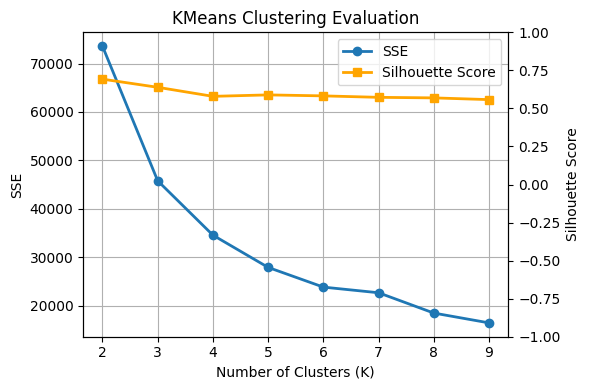

In [ ]:
import joblib

author_score = joblib.load("author_clustering_metrics.score")

k_values = list(range(2, 10))
sse = author_score["sse"]
sc = author_score["sc"]

plot_kmeans_metrics(k_values, sse, sc)


In [ ]:
import pandas as pd
import joblib

# 1. Load the model
author_km = joblib.load('author_k4.model')

# 2. Cluster centers
author_centers = pd.DataFrame(
author_km.cluster_centers_,
columns=author_feature.columns
)

# 3. Predict labels
cluster_labels = author_km.predict(author_data)

# 4. Number of authors in each cluster, sorted by cluster_id
cluster_counts = (
pd.Series(cluster_labels)
.value_counts()
.sort_index()
)

# 5. Safely merge
author_centers['num_authors'] = cluster_counts.values

# 6. Explicitly set cluster_id
author_centers['cluster_id'] = author_centers.index
author_centers = author_centers.set_index('cluster_id')

author_centers

,author_id,total_views,total_likes,total_finishes,total_items,avg_item_duration,unique_music_count,unique_post_days,unique_cities,num_authors
cluster_id,,,,,,,,,,
0,141948.657294,11.921919,0.121943,5.106954,3.502643,10.835171,3.127985,3.502527,1.109801,17190
1,577267.809562,8.020665,0.058549,3.788088,1.560373,10.793188,1.489668,1.560170,1.049433,4933
2,280990.889258,10.147406,0.094945,4.589707,2.393415,10.680454,2.211506,2.393415,1.091453,12008
3,40672.333238,41.791922,0.394750,17.797407,6.410529,10.834166,5.200776,6.410137,1.160671,28122


### Association Rules

In [ ]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

# 1) Load data (use English file name if possible)

user_df = pd.read_csv("user characteristics.csv")


# 2) Drop ID-like columns (important!)
id_cols = [c for c in user_df.columns if c.lower() in ["uid", "user_id", "id"]]
user_df = user_df.drop(columns=id_cols, errors="ignore")

# 3) Convert to transaction-style 0/1 (bool) matrix
#    Rule of thumb: >0 means "has / did / used", 0 means "not"
# 3) Make meaningful binary features (use median thresholds)
binary_df = pd.DataFrame({
    "high_views": user_df["Views"] > user_df["Views"].median(),
    "high_likes": user_df["Likes"] > user_df["Likes"].median(),
    "many_viewed_works": user_df["Number of viewed works"] > user_df["Number of viewed works"].median(),
    "long_watch_time": user_df["Average viewing time"] > user_df["Average viewing time"].median(),
    "many_cities": user_df["number of cities visited"] > user_df["number of cities visited"].median(),
    "many_cities_viewed_works": user_df["number of cities viewed works"] > user_df["number of cities viewed works"].median(),
    "many_authors": user_df["Views by Authors"] > user_df["Views by Authors"].median(),
    "many_bg_music": user_df["Number of viewed background music"] > user_df["Number of viewed background music"].median(),
    "high_complete_views": user_df["Number of complete views"] > user_df["Number of complete views"].median(),
}).astype(bool)


# 4) Apriori: frequent itemsets
min_support = 0.20
frequent_itemsets = apriori(binary_df, min_support=min_support, use_colnames=True)

# 5) Association rules
min_confidence = 0.70
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=min_confidence)

# 6) Optional: filter + sort (so it’s readable)
filtered_rules = (
    rules[(rules["support"] >= min_support) & (rules["confidence"] >= min_confidence)]
    .sort_values(["confidence", "lift", "support"], ascending=False)
)

# 7) Pretty print (top N)
top_n = 20
for _, row in filtered_rules.head(top_n).iterrows():
    antecedents = ", ".join(sorted(list(row["antecedents"])))
    consequents = ", ".join(sorted(list(row["consequents"])))
    print(f"Rule: {antecedents}  ->  {consequents}")
    print(f"  support   : {row['support']:.3f}")
    print(f"  confidence: {row['confidence']:.3f}")
    print(f"  lift      : {row['lift']:.3f}")
    print("-" * 40)



Rule: many_authors  ->  many_viewed_works
  support   : 0.490
  confidence: 1.000
  lift      : 2.029
----------------------------------------
Rule: high_views, many_authors  ->  many_viewed_works
  support   : 0.490
  confidence: 1.000
  lift      : 2.029
----------------------------------------
Rule: many_authors  ->  high_views, many_viewed_works
  support   : 0.490
  confidence: 1.000
  lift      : 2.029
----------------------------------------
Rule: many_bg_music  ->  many_viewed_works
  support   : 0.485
  confidence: 1.000
  lift      : 2.029
----------------------------------------
Rule: high_views, many_bg_music  ->  many_viewed_works
  support   : 0.485
  confidence: 1.000
  lift      : 2.029
----------------------------------------
Rule: many_bg_music  ->  high_views, many_viewed_works
  support   : 0.485
  confidence: 1.000
  lift      : 2.029
----------------------------------------
Rule: many_authors, many_bg_music  ->  many_viewed_works
  support   : 0.483
  confidence: 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import pandas as pd

author_df = pd.read_csv("author_features.csv")

# 1
print(author_df.columns.tolist())

# 2️
author_df.head()


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

['author_id', 'total_views', 'total_likes', 'total_finishes', 'total_items', 'avg_item_duration', 'unique_music_count', 'unique_post_days', 'unique_cities']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,author_id,total_views,total_likes,total_finishes,total_items,avg_item_duration,unique_music_count,unique_post_days,unique_cities
0,0,1,0,0,1,10.000000,1,1,1
1,1,16,0,8,3,8.333333,3,3,1
2,3,311,3,203,1,9.000000,1,1,1
3,5,1054,33,485,5,8.200000,4,5,1
4,8,4,0,3,1,19.000000,1,1,1


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

# 1) load
author_df = pd.read_csv("author_features.csv")

# 2) drop id columns
author_df = author_df.drop(columns=["author_id"], errors="ignore")

# 3) build meaningful binary features (quantile threshold)
q = 0.75  # try 0.5 if you want looser rules

binary_df = pd.DataFrame({
    "high_total_views": author_df["total_views"] > author_df["total_views"].quantile(q),
    "high_total_likes": author_df["total_likes"] > author_df["total_likes"].quantile(q),
    "high_total_finishes": author_df["total_finishes"] > author_df["total_finishes"].quantile(q),
    "many_total_items": author_df["total_items"] > author_df["total_items"].quantile(q),
    "long_avg_item_duration": author_df["avg_item_duration"] > author_df["avg_item_duration"].quantile(q),
    "many_unique_music": author_df["unique_music_count"] > author_df["unique_music_count"].quantile(q),
    "many_unique_post_days": author_df["unique_post_days"] > author_df["unique_post_days"].quantile(q),
    "many_unique_cities": author_df["unique_cities"] > author_df["unique_cities"].quantile(q),
}).astype(bool)

# 4) apriori
min_support = 0.05
freq = apriori(binary_df, min_support=min_support, use_colnames=True)

# 5) rules
min_confidence = 0.6
rules = association_rules(freq, metric="confidence", min_threshold=min_confidence)

# 6) filter & sort
filtered = (
    rules[(rules["support"] >= min_support) & (rules["confidence"] >= min_confidence)]
    .sort_values(["confidence", "lift", "support"], ascending=False)
)

# 7) print top N
top_n = 20
for _, row in filtered.head(top_n).iterrows():
    a = ", ".join(sorted(list(row["antecedents"])))
    c = ", ".join(sorted(list(row["consequents"])))
    print(f"Rule: {a} -> {c}")
    print(f"  support   : {row['support']:.3f}")
    print(f"  confidence: {row['confidence']:.3f}")
    print(f"  lift      : {row['lift']:.3f}")
    print("-" * 40)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Rule: high_total_views, long_avg_item_duration, many_total_items -> many_unique_post_days
  support   : 0.069
  confidence: 1.000
  lift      : 5.602
----------------------------------------
Rule: high_total_views, long_avg_item_duration, many_unique_music -> many_unique_post_days
  support   : 0.064
  confidence: 1.000
  lift      : 5.602
----------------------------------------
Rule: high_total_views, long_avg_item_duration, many_total_items, many_unique_music -> many_unique_post_days
  support   : 0.064
  confidence: 1.000
  lift      : 5.602
----------------------------------------
Rule: high_total_views, long_avg_item_duration, many_unique_music -> many_total_items, many_unique_post_days
  support   : 0.064
  confidence: 1.000
  lift      : 5.602
----------------------------------------
Rule: high_total_finishes, long_avg_item_duration, many_total_items -> many_unique_post_days
  support   : 0.054
  confidence: 1.000
  lift      : 5.602
----------------------------------------
Rul

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

###  Binary Classification Model Evaluation and Optimization

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
from sklearn import ensemble
from sklearn.model_selection import GridSearchCV

import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['font.size'] = 20

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
sx_data = pd.read_csv('douyin_dataset.csv')
del sx_data['Unnamed: 0'], sx_data['H'], sx_data['date'], sx_data['finish'], sx_data['channel']
sx_data.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,uid,user_city,item_id,author_id,item_city,like,music_id,duration_time,real_time
0,15692,109.0,691661,18212,213.0,0,11513.0,10,2019-10-28 21:55:10
1,44071,80.0,1243212,34500,68.0,0,1274.0,9,2019-10-21 22:27:03
2,10902,202.0,3845855,634066,113.0,0,762.0,10,2019-10-26 00:38:51
3,25300,21.0,3929579,214923,330.0,0,2332.0,15,2019-10-25 20:36:25
4,3656,138.0,2572269,182680,80.0,0,238.0,9,2019-10-21 20:46:29


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
sx_data_like = sx_data[sx_data['like']==1]
sx_data_dislike = sx_data[sx_data['like']==0]
data = pd.concat([sx_data_like[::20], sx_data_dislike[::40]], axis=0)
print(len(data)/len(sx_data))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

0.02524186789707318


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
from sklearn.model_selection import train_test_split

X = sx_data.drop(columns=["like"])
y = sx_data["like"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,      #
    random_state=42
)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
flag = pd.to_datetime('2019-01-01 00:00:00')
data['real_time'] = pd.to_datetime(data['real_time'])
data['real_time'] = pd.to_timedelta( data['real_time'] - flag).dt.total_seconds()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
data.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,uid,user_city,item_id,author_id,item_city,like,music_id,duration_time,real_time
134,32039,2.0,1324665,48937,15.0,1,578.0,10,24181411.0
2181,14571,142.0,2489542,37131,229.0,1,1318.0,7,25305835.0
3955,25090,136.0,1582882,16382,69.0,1,680.0,10,23180382.0
5685,11153,73.0,209250,28248,137.0,1,4545.0,9,24856880.0
8647,2159,106.0,1019916,246,18.0,1,3928.0,9,25677638.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
xtrain,xtest, ytrain, ytest = \
    train_test_split(
        data.drop('like', axis=1), # X
        data['like'],test_size=0.3, # Y
        random_state=0 # random_seed
    )

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
def train(name, model):
    model = model.fit(xtrain, ytrain)
    print(f'{name} accuracy:\t{model.score(xtest, ytest)}')
    return model


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# Logistic Regression
lgs = train('lgs', LogisticRegression(solver='liblinear', C=100.0, random_state=1))

# Naive Bayes
gnb = train('gnb', GaussianNB())

# Decision Tree
clf = train('clf', DecisionTreeClassifier(class_weight='balanced', random_state=0))

# Random Forest
rfc = train('rfc', RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=0
))


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

lgs accuracy:	0.9805411979325023
gnb accuracy:	0.9801611432046214


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

clf accuracy:	0.9601702645180906


Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac

rfc accuracy:	0.9805411979325023


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
def my_auc(model):
    y_test_proba = model.predict_proba(xtest)
    false_positive_rate, recall, thresholds = roc_curve(ytest, y_test_proba[:, 1])
    roc_auc = auc(false_positive_rate, recall)
    return false_positive_rate, recall, roc_auc


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
def my_auc(model):
    # Model with predict_proba
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(xtest)[:, 1]
    # Model with only decision_function
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(xtest)
    else:
        raise ValueError("Model does not support probability or decision scores")

    fpr, tpr, _ = roc_curve(ytest, y_score)
    roc_auc = auc(fpr, tpr)
    return fpr, tpr, roc_auc


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
lgs_auc = my_auc(lgs)
gnb_auc = my_auc(gnb)
clf_auc = my_auc(clf)
rfc_auc = my_auc(rfc)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

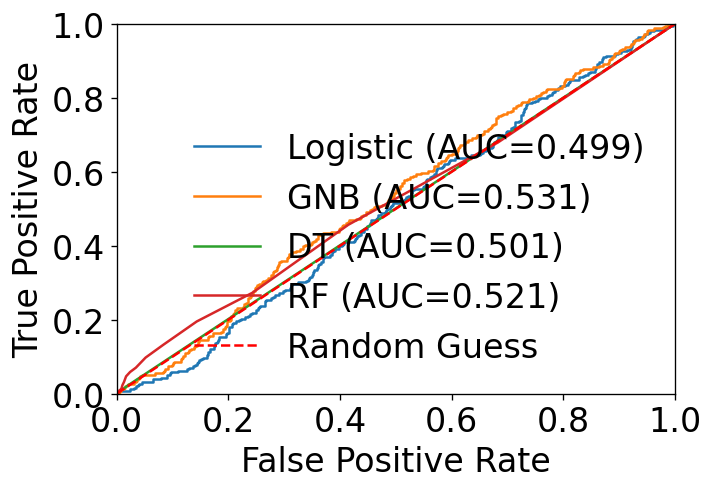

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
plt.figure(figsize=(6,4), dpi=120)

plt.plot(lgs_auc[0], lgs_auc[1], label='Logistic (AUC=%.3f)' % lgs_auc[2])
plt.plot(gnb_auc[0], gnb_auc[1], label='GNB (AUC=%.3f)' % gnb_auc[2])
plt.plot(clf_auc[0], clf_auc[1], label='DT (AUC=%.3f)' % clf_auc[2])
plt.plot(rfc_auc[0], rfc_auc[1], label='RF (AUC=%.3f)' % rfc_auc[2])

plt.plot([0, 1], [0, 1], 'r--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right', frameon=False)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.show()


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

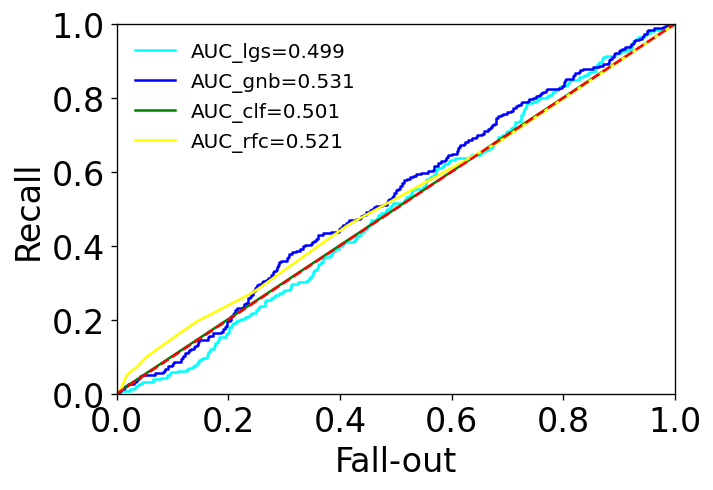

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# Draw a graph showing the ROC curves of the two models.
plt.figure(figsize=(6,4),dpi=120)
plt.plot(lgs_auc[0], lgs_auc[1], color='cyan', label='AUC_lgs=%0.3f' % lgs_auc[2])
plt.plot(gnb_auc[0], gnb_auc[1], color='blue', label='AUC_gnb=%0.3f' % gnb_auc[2])
plt.plot(clf_auc[0], clf_auc[1], color='green', label='AUC_clf=%0.3f' % clf_auc[2])
plt.plot(rfc_auc[0], rfc_auc[1], color='yellow', label='AUC_rfc=%0.3f' % rfc_auc[2])
plt.legend(loc='best', fontsize=12, frameon=False)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.ylabel('Recall')
plt.xlabel('Fall-out')
plt.show()

In [ ]:
import time
from sklearn.ensemble import RandomForestClassifier

t0 = time.perf_counter()
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=0,
    n_jobs=-1
)
rf.fit(xtrain, ytrain)
t1 = time.perf_counter()

print("One fit (100 trees) seconds:", t1 - t0)


Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac

One fit (100 trees) seconds: 19.40382175099876


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)


In [ ]:
params = {"n_estimators": [100, 200]}

grid = GridSearchCV(
    RandomForestClassifier(
        class_weight="balanced",
        random_state=0,
        n_jobs=-1
    ),
    params,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(xtrain, ytrain)
grid.best_params_, grid.best_score_


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Fitting 3 folds for each of 2 candidates, totalling 6 fits


Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac

({'n_estimators': 200}, np.float64(0.5787349384349342))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
grid.best_params_, grid.best_score_


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

({'n_estimators': 200}, np.float64(0.5787349384349342))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
print("grid exists:", "grid" in globals())
print("has best_params_:", hasattr(grid, "best_params_"))
print("has best_score_:", hasattr(grid, "best_score_"))


grid exists: True
has best_params_: True
has best_score_: True


In [ ]:
print("best params:", grid.best_params_)
print("best score:", grid.best_score_)


best params: {'n_estimators': 200}
best score: 0.5787349384349342


In [ ]:
params = {
    "n_estimators": [100, 300, 500]
}

grid = GridSearchCV(
    RandomForestClassifier(
        class_weight="balanced",
        random_state=0,
        n_jobs=-1
    ),
    params,
    scoring="roc_auc",
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid.fit(xtrain, ytrain)
grid.best_params_, grid.best_score_


In [ ]:
params = {
    'n_estimators': [x for x in range(100,1500,100)]
}
grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=0),
    params, scoring="roc_auc",
    cv=3, verbose=1, n_jobs=-1
).fit(xtrain, ytrain)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Fitting 3 folds for each of 14 candidates, totalling 42 fits


Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac

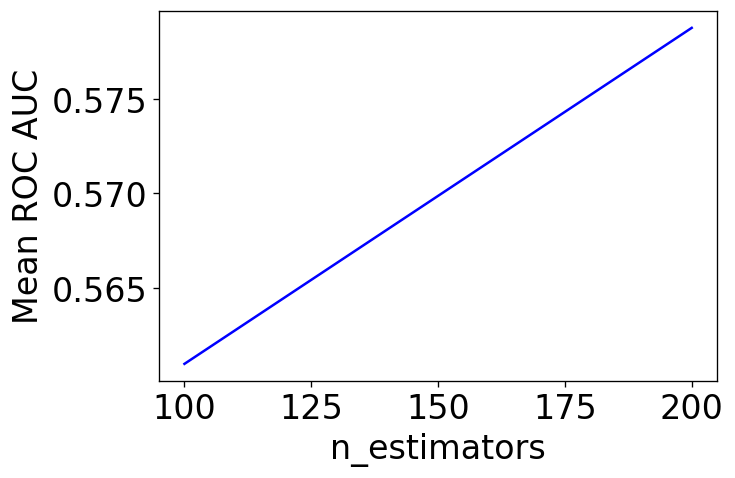

{'n_estimators': 200}

In [ ]:
results = grid.cv_results_
x = results['param_n_estimators'].data.astype(int)
y = results['mean_test_score']

plt.figure(figsize=(6,4), dpi=120)
plt.plot(x, y, color='blue')
plt.xlabel('n_estimators')
plt.ylabel('Mean ROC AUC')
plt.show()

grid.best_params_


In [ ]:
grid.best_params_

{'n_estimators': 200}

In [ ]:
params = {"max_features": [2, 4, 6]}

grid = GridSearchCV(
    RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=0,
        n_jobs=-1        #
    ),
    params,
    scoring="roc_auc",
    cv=2,
    verbose=1,
    n_jobs=-1
)

grid.fit(xtrain, ytrain)


Fitting 2 folds for each of 3 candidates, totalling 6 fits


GridSearchCV(cv=2,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              n_estimators=200, n_jobs=-1,
                                              random_state=0),
             n_jobs=-1, param_grid={'max_features': [2, 4, 6]},
             scoring='roc_auc', verbose=1)

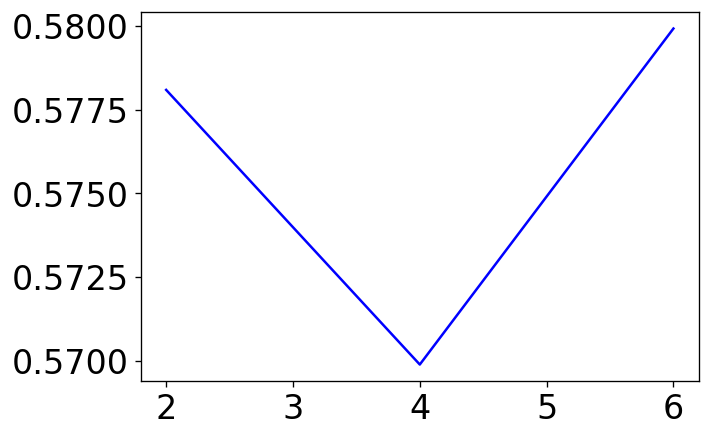

In [ ]:
a = grid.cv_results_['mean_test_score']
plt.figure(figsize=(6,4),dpi=120)
plt.plot(params['max_features'], a, color='blue')
plt.show()

In [ ]:
grid.best_params_

{'max_features': 6}

In [ ]:
rfc0 = RandomForestClassifier(
    n_estimators=200,        # ← GridSearch best
    max_features=6,
    class_weight='balanced',
    random_state=0,
    n_jobs=-1                #
)
rfc0 = train('rfc++', rfc0)


rfc++ accuracy:	0.9805411979325023


Based on cross-validation results, I fixed the number of trees at 200, as increasing the ensemble size further led to marginal performance gains with significantly higher computational cost.

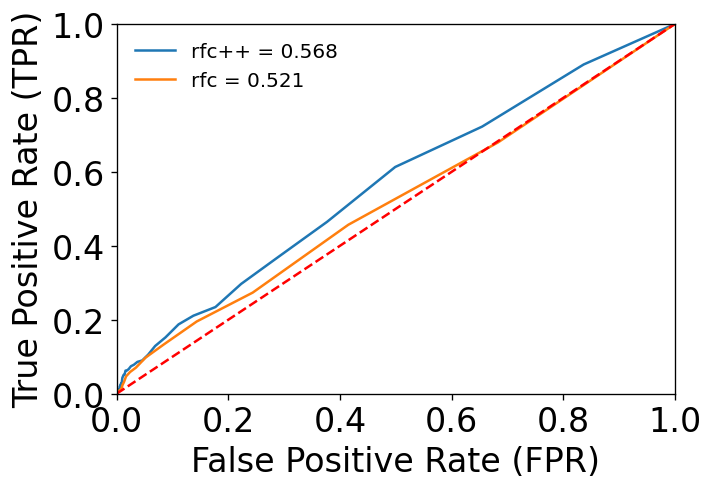

In [ ]:
auc_rfc0 = my_auc(rfc0)

# Draw ROC curves for the two models
plt.figure(figsize=(6, 4), dpi=120)

plt.plot(auc_rfc0[0], auc_rfc0[1], label='rfc++ = %0.3f' % auc_rfc0[2])
plt.plot(rfc_auc[0], rfc_auc[1], label='rfc = %0.3f' % rfc_auc[2])

plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')

plt.legend(loc='best', fontsize=12, frameon=False)
plt.show()


In [ ]:
sx_data.head()

,uid,user_city,item_id,author_id,item_city,like,music_id,duration_time,real_time
0,15692,109.0,691661,18212,213.0,0,11513.0,10,2019-10-28 21:55:10
1,44071,80.0,1243212,34500,68.0,0,1274.0,9,2019-10-21 22:27:03
2,10902,202.0,3845855,634066,113.0,0,762.0,10,2019-10-26 00:38:51
3,25300,21.0,3929579,214923,330.0,0,2332.0,15,2019-10-25 20:36:25
4,3656,138.0,2572269,182680,80.0,0,238.0,9,2019-10-21 20:46:29


In [ ]:
flag = pd.to_datetime('2019-01-01 00:00:00')
sx_data['real_time'] = pd.to_datetime(sx_data['real_time'])
sx_data['real_time'] = pd.to_timedelta(sx_data['real_time'] - flag).dt.total_seconds()

In [ ]:
rfc0.score(sx_data.drop('like', axis=1), sx_data['like'])

0.9906533771711702

In [ ]:
lk = sx_data['like'].value_counts()
lk

,count
like,
0,1720539
1,16773


In [ ]:
lk[0]/lk.sum()

np.float64(0.9903454301817981)